# Convertible Bond Pricer Using QuantLib


In [426]:
import QuantLib as ql
print(ql.__version__)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1.32


In [427]:
calculation_date = ql.Date(22,2,2022)
ql.Settings.instance().evaluationDate = calculation_date

In [428]:
# St. Mary Land & Exploration Company 
# Bloomberg ticker: SM 5.75 03/15/22 

redemption = 100.00
face_amount = 100.0
spot_price = 3.02
conversion_price = 7.068
conversion_ratio = 14.14827

issue_date = ql.Date(30,1,2013)        
maturity_date = ql.Date(1,2,2033)

settlement_days = 2
calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
coupon = 0.03
frequency = ql.Semiannual
tenor = ql.Period(frequency)

day_count = ql.Thirty360(ql.Thirty360.BondBasis)
accrual_convention = ql.Unadjusted
payment_convention = ql.Unadjusted

call_dates = [ql.Date(1,2,2019)]
call_price = 100.0
put_dates = [ql.Date(1,2,2019), ql.Date(1,2,2023), ql.Date(1,2,2028)]
put_price = 100.0

# assumptions
dividend_yield = 0
credit_spread_rate = 0.04
# risk_free_rate = 0.04 # we will use the swap curve as the risk-free curve
volatility = 0.30

In [429]:
## reading the swap curve data from the Excel file
file_path = "US Swap Curve 20230221.xlsx"
df = pd.read_excel(file_path)

curve_data = df.iloc[2:, 2:4]
curve_data.columns = ["Term", "Rate"]
curve_data = curve_data.dropna()

In [430]:
helpers = []

for _, row in curve_data.iterrows():

    term = row["Term"]
    rate = float(row["Rate"]) / 100.0

    if "MO" in term:
        n = int(term.split()[0])
        period = ql.Period(n, ql.Months)

    elif "YR" in term:
        n = int(term.split()[0])
        period = ql.Period(n, ql.Years)

    helper = ql.SwapRateHelper(
        ql.QuoteHandle(ql.SimpleQuote(rate)),
        period,
        calendar,
        ql.Annual,
        ql.Unadjusted,
        ql.Thirty360(ql.Thirty360.BondBasis),
        ql.USDLibor(ql.Period(3, ql.Months))
    )

    helpers.append(helper)

In [431]:
## yield curve construction
swap_curve = ql.PiecewiseLinearZero(
    calculation_date,
    helpers,
    ql.Actual365Fixed()
)

yield_ts_handle = ql.YieldTermStructureHandle(swap_curve)

In [432]:
callability_schedule = ql.CallabilitySchedule()


for call_date in call_dates:
   callability_price  = ql.BondPrice(call_price, 
                                            ql.BondPrice.Clean)
   callability_schedule.append(ql.Callability(callability_price, 
                                       ql.Callability.Call,
                                       call_date)
                        )
    
for put_date in put_dates:
    puttability_price = ql.BondPrice(put_price, 
                                            ql.BondPrice.Clean)
    callability_schedule.append(ql.Callability(puttability_price,
                                               ql.Callability.Put,
                                               put_date))

In [433]:
dividend_schedule = ql.DividendSchedule() # No dividends
dividend_amount = dividend_yield*spot_price
next_dividend_date = ql.Date(1,12,2004)
dividend_amount = spot_price*dividend_yield
for i in range(4):
    date = calendar.advance(next_dividend_date, 1, ql.Years)
    dividend_schedule.append(
        ql.FixedDividend(dividend_amount, date)
    )

In [434]:
schedule = ql.Schedule(issue_date, maturity_date, tenor,
                       calendar, accrual_convention, accrual_convention,
                       ql.DateGeneration.Backward, False)

credit_spread_handle = ql.QuoteHandle(ql.SimpleQuote(credit_spread_rate))
exercise = ql.AmericanExercise(calculation_date, maturity_date)

convertible_bond = ql.ConvertibleFixedCouponBond(exercise,
                                                     conversion_ratio,
                                                     callability_schedule, 
                                                     issue_date,
                                                     settlement_days,
                                                     [coupon],
                                                     day_count,
                                                     schedule,
                                                     redemption)

In [435]:
spot_price_handle = ql.QuoteHandle(ql.SimpleQuote(spot_price))

# yield_ts_handle = ql.YieldTermStructureHandle(
#     ql.FlatForward(calculation_date, risk_free_rate, day_count)
# )

dividend_ts_handle = ql.YieldTermStructureHandle(
    ql.FlatForward(calculation_date, dividend_yield, day_count)
)
volatility_ts_handle = ql.BlackVolTermStructureHandle(
    ql.BlackConstantVol(calculation_date, calendar,volatility, day_count)
)

bsm_process = ql.BlackScholesMertonProcess(spot_price_handle, 
                                           dividend_ts_handle,
                                           yield_ts_handle,
                                           volatility_ts_handle)

In [436]:
time_steps = 1000
engine = ql.BinomialConvertibleEngine(bsm_process, "crr", time_steps, credit_spread_handle, dividend_schedule)

In [437]:
convertible_bond.setPricingEngine(engine)
print ("NPV ", convertible_bond.NPV())
print ("Accrued ", convertible_bond.accruedAmount())

NPV  96.76327036710182
Accrued  0.19166666666665666


# Greeks Calculation

In [438]:
spot_quote = ql.SimpleQuote(spot_price)
spot_handle = ql.QuoteHandle(spot_quote)

vol_quote = ql.SimpleQuote(volatility)
vol_ts = ql.BlackVolTermStructureHandle(
    ql.BlackConstantVol(
        calculation_date,
        calendar,
        ql.QuoteHandle(vol_quote),
        day_count
    )
)

In [439]:
bsm_process = ql.BlackScholesMertonProcess(
    spot_handle,
    dividend_ts_handle,
    risk_free_ts,
    vol_ts
)

# Rebuild Engine
engine = ql.BinomialConvertibleEngine(
    bsm_process,
    "crr",
    1000,
    credit_spread_handle
)

convertible_bond.setPricingEngine(engine)

In [440]:
## DELTA & GAMMA (1% Stock Move)

price_0 = convertible_bond.NPV()

bump = 0.01
S0 = spot_quote.value()

# Up move (+1%)
spot_quote.setValue(S0 * (1 + bump))
price_up = convertible_bond.NPV()

# Down move (-1%)
spot_quote.setValue(S0 * (1 - bump))
price_down = convertible_bond.NPV()

# Reset spot
spot_quote.setValue(S0)

# ---- Parity (required by PDF) ----
parity = S0 * conversion_ratio

# ---- Delta (using parity denominator) ----
delta = (price_up - price_down) / (2 * parity)

# ---- Gamma (still based on 1% move) ----
gamma = (price_up - 2 * price_0 + price_down) / (parity * bump)

print(f"Delta:", delta)
print(f"Gamma:", gamma)

Delta: 0.0004867853838980832
Gamma: 6.651811184722714e-14


In [441]:
## VEGA (1% Vol Change)

vol0 = vol_quote.value()

# Up vol
vol_quote.setValue(vol0 + 0.01)
price_up = convertible_bond.NPV()

# Down vol
vol_quote.setValue(vol0 - 0.01)
price_down = convertible_bond.NPV()

# Reset
vol_quote.setValue(vol0)

vega = (price_up - price_down) / 2

print("Vega:", vega)

Vega: 0.0801386714602188


In [442]:
## RHO (100bp Yield Curve Shift)

shift = 0.01  # 100bp

spreaded_curve = ql.ZeroSpreadedTermStructure(
    risk_free_ts,
    ql.QuoteHandle(ql.SimpleQuote(shift))
)

shifted_handle = ql.YieldTermStructureHandle(spreaded_curve)

bsm_process_shifted = ql.BlackScholesMertonProcess(
    spot_handle,
    dividend_ts_handle,
    shifted_handle,
    vol_ts
)

engine_shifted = ql.BinomialConvertibleEngine(
    bsm_process_shifted,
    "crr",
    1000,
    credit_spread_handle
)

convertible_bond.setPricingEngine(engine_shifted)

price_shifted = convertible_bond.NPV()

rho = price_shifted - price_0

print("Rho (100bp):", rho)

Rho (100bp): -0.8709626843426292


## Bond floor curve

In [443]:
risky_curve = ql.ZeroSpreadedTermStructure(
    risk_free_ts,
    ql.QuoteHandle(ql.SimpleQuote(credit_spread_rate))
)

risky_handle = ql.YieldTermStructureHandle(risky_curve)

In [444]:
time_steps = 100

maturity_time = day_count.yearFraction(
    calculation_date,
    maturity_date
)

time_grid = np.linspace(0, maturity_time - 1e-6, time_steps)

In [445]:
bond_floor_values = []

for t in time_grid:

    future_date = calendar.advance(
        calculation_date,
        int(t * 365),
        ql.Days
    )

    if future_date >= maturity_date:
        break   # stop computation

    pv = 0.0

    for cf in convertible_bond.cashflows():
        if cf.date() > future_date:
            df_cf = risky_handle.discount(cf.date())
            df_t = risky_handle.discount(future_date)
            pv += cf.amount() * df_cf / df_t

    bond_floor_values.append(pv)

time_grid = time_grid[:len(bond_floor_values)]

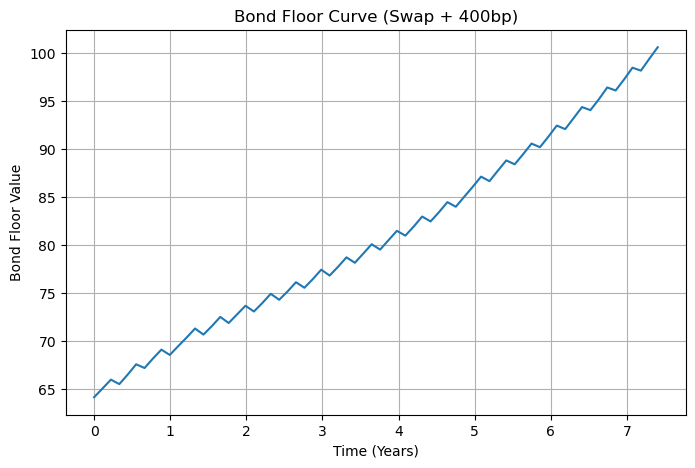

In [446]:
plt.figure(figsize=(8,5))
plt.plot(time_grid, bond_floor_values)
plt.xlabel("Time (Years)")
plt.ylabel("Bond Floor Value")
plt.title("Bond Floor Curve (Swap + 400bp)")
plt.grid(True)
plt.show()